Zadanie 12

Przeanalizuj learning curves dla modelu.

Dataset: California Housing

Wymagania:
- Wygeneruj learning curves dla SGDRegressor
- Zidentyfikuj, czy model ma underfitting/overfitting
- Zaproponuj rozwiązanie

Oczekiwany rezultat:
- Wykres learning curves
- Diagnoza i rekomendacje

=== Podział danych ===
Zbiór treningowy:   16512 (80%)
Zbiór testowy:      4128 (20%)
Razem:              20640 (100%)



=== Learning Curves Analysis ===
Rozmiary treningowe: [ 1320  2641  3962  5283  6604  7925  9246 10567 11888 13209]

Końcowy błąd treningowy (MSE): 0.5851
Końcowy błąd walidacji (MSE): 0.5865
Gap: 0.0015

DIAGNOZA: Underfitting (Niedouczenie)
REKOMENDACJE:
- Model jest zbyt prosty dla tego zbioru danych.
- Dodaj cechy wielomianowe używając 'PolynomialFeatures'.
- Zmień model na nieliniowy (np. RandomForestRegressor lub GradientBoostingRegressor).


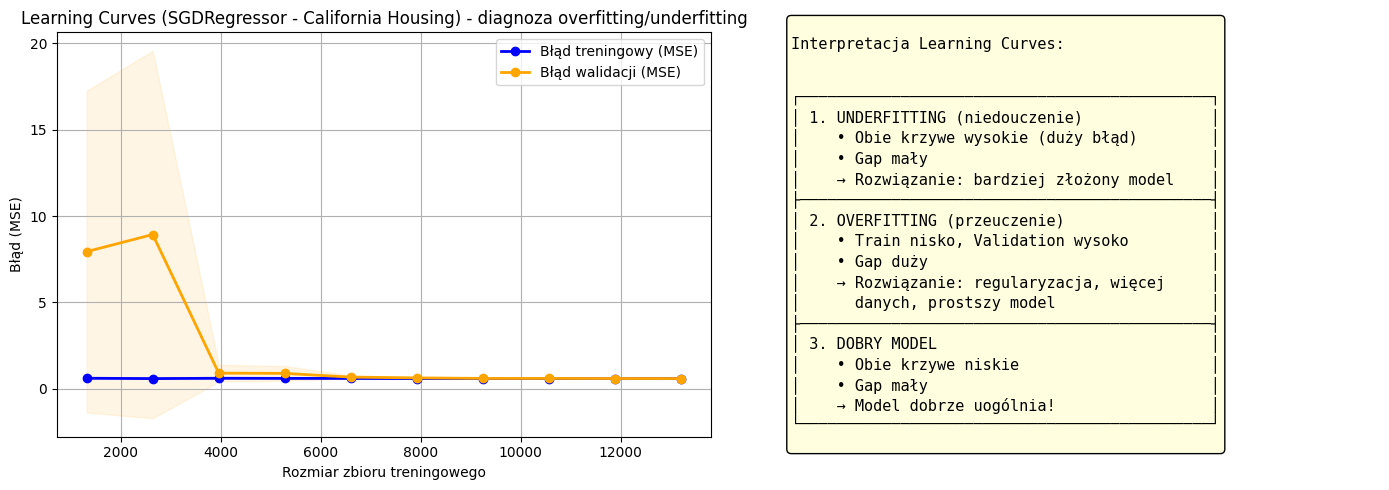

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline

# Ładowanie i przygotowanie danych
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Podział danych ===")
print(f"Zbiór treningowy:   {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Zbiór testowy:      {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Razem:              {len(X)} (100%)")

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(learning_rate='constant', eta0=0.00001,
                           max_iter=1000, random_state=42))
])

# Generowanie Learning curves
train_sizes, train_scores, validation_scores = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Używany MSE do oceny
    n_jobs=-1
)

# Konwersja na MSE, obliczanie średnich i odchyleń standardowych
train_scores_mean = -train_scores.mean(axis=1) # Minus, bo neg_MSE
train_scores_std = train_scores.std(axis=1)
validation_scores_mean = -validation_scores.mean(axis=1)
validation_scores_std = validation_scores.std(axis=1)

# Diagnoza modelu
final_train_mse = train_scores_mean[-1]
final_val_mse = validation_scores_mean[-1]
gap = final_val_mse - final_train_mse

print("\n=== Learning Curves Analysis ===")
print(f"Rozmiary treningowe: {train_sizes}")
print(f"\nKońcowy błąd treningowy (MSE): {final_train_mse:.4f}")
print(f"Końcowy błąd walidacji (MSE): {final_val_mse:.4f}")
print(f"Gap: {gap:.4f}")

HIGH_ERROR_THRESHOLD = 0.5 
SIGNIFICANT_GAP_THRESHOLD = 0.1

if final_train_mse > HIGH_ERROR_THRESHOLD and gap < SIGNIFICANT_GAP_THRESHOLD:
    print("\nDIAGNOZA: Underfitting (Niedouczenie)")
    print("REKOMENDACJE:")
    print("- Model jest zbyt prosty dla tego zbioru danych.")
    print("- Dodaj cechy wielomianowe używając 'PolynomialFeatures'.")
    print("- Zmień model na nieliniowy (np. RandomForestRegressor lub GradientBoostingRegressor).")

elif gap > SIGNIFICANT_GAP_THRESHOLD:
    print("\nDIAGNOZA: Overfitting (Przeuczenie)")
    print("REKOMENDACJE:")
    print("- Zwiększ regularyzację (np. zwiększ parametr 'alpha' w SGDRegressor).")
    print("- Zredukuj liczbę cech (Feature Selection).")
    print("- Pozyskaj więcej danych treningowych.")

else:
    print("\nDIAGNOZA: Model jest dobrze dopasowany (Good Fit)")
    print("REKOMENDACJE:")
    print("- Model osiągnął optymalny balans.")
    print("- Możesz spróbować delikatnego tuningu hiperparametrów, aby jeszcze bardziej obniżyć błąd.")

# Wizualizacja Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curves
axes[0].plot(train_sizes, train_scores_mean, 'o-', label='Błąd treningowy (MSE)', 
             color='blue', linewidth=2)
axes[0].plot(train_sizes, validation_scores_mean, 'o-', label='Błąd walidacji (MSE)',
             color='orange', linewidth=2)

# Cieniowanie obszarów odchylenia standardowego
axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="blue")
axes[0].fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                     validation_scores_mean + validation_scores_std, alpha=0.1, 
                     color="orange")

axes[0].set_title('Learning Curves (SGDRegressor - California Housing) - diagnoza overfitting/underfitting')
axes[0].set_xlabel('Rozmiar zbioru treningowego')
axes[0].set_ylabel('Błąd (MSE)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Schemat interpretacji
axes[1].axis('off')
interpretations = """
Interpretacja Learning Curves:


┌─────────────────────────────────────────────┐
│ 1. UNDERFITTING (niedouczenie)              │
│    • Obie krzywe wysokie (duży błąd)        │
│    • Gap mały                               │
│    → Rozwiązanie: bardziej złożony model    │
├─────────────────────────────────────────────┤
│ 2. OVERFITTING (przeuczenie)                │
│    • Train nisko, Validation wysoko         │
│    • Gap duży                               │
│    → Rozwiązanie: regularyzacja, więcej     │
│      danych, prostszy model                 │
├─────────────────────────────────────────────┤
│ 3. DOBRY MODEL                              │
│    • Obie krzywe niskie                     │
│    • Gap mały                               │
│    → Model dobrze uogólnia!                 │
└─────────────────────────────────────────────┘
"""
axes[1].text(0.1, 0.5, interpretations, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

